# Capstone: Define and Solve an ML Problem

In [1]:
import pandas as pd
import numpy as np
import os 
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder 
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
import tensorflow.keras as keras
from sklearn.preprocessing import StandardScaler
import time

**Note**: As you work through the notebook, you can import additional packages as needed.

## Overview


In this capstone assignment, you will follow the machine learning life cycle and implement one of the supervised learning models you have learned so far in this course, along with a neural network, to solve a predictive problem.

This capstone spans two lab sessions.

- **Unit 5 Lab:** You will define a machine learning problem, explore and prepare your data, and train, test, evaluate and improve a traditional machine learning model (Parts 1–5).
- **Unit 6 Lab:** After completing Unit 6 on neural networks, you will apply a neural network to the same problem and compare the two approaches (Parts 6–7).

There is a checkpoint at the end of Part 5 that marks where to stop during the Unit 5 lab.

You will complete the following:

1. Choose your Data Set and Build Your DataFrame
2. Define Your ML Problem
3. Understand Your Data
4. Prepare Your Data
5. Train, Test, Evaluate and Improve a Traditional Machine Learning Model *(Unit 5 lab)*
6. Train, Test, Evaluate and Improve Neural Network *(Unit 6 lab)*
7. Compare Your Models and Reflect *(Unit 6 lab)*

**This is an individual assignment.** You are welcome to discuss ideas with your peers, but the code and written responses you submit must be your own.

**Note:** This capstone is intentionally less scaffolded than your weekly labs; that is by design. You are expected to make your own implementation choices, add code cells as needed, and document your reasoning throughout.

## Part 1: Choose Your Data Set and Build Your DataFrame


You will choose one of two data sets to work with for this capstone. In both cases, you will be solving a supervised learning binary classification problem by predicting one of two possible class labels. Both data sets have been used earlier in the course, so you are already familiar with their structure. 

**Option A: Census Income Data** (`censusData.csv`)
This data set contains demographic and employment information from the 1994 U.S. Census. You will use it to predict whether an individual's annual income exceeds $50,000. Your label column is `income_binary`, which contains two values: `<=50K` and `>50K`. You will need to convert this column into a binary numeric label (for example, 0 and 1) during data preparation.

**Option B: Airbnb NYC Listings Data** (`airbnbListingsData.csv`)
This data set contains information about Airbnb listings in New York City. You will use it to predict whether a listing is high-priced. The data set includes a new `price_category` column that classifies each listing as either "high price" or "low price" based on whether the listing’s price falls above or below the 75th percentile of all listing prices. Listings at or above the 75th percentile are labeled as `high`, while the remaining listings are labeled as `low`. You will need to convert this column into a binary numeric label (for example, 0 and 1) during data preparation.

**Note:**  These versions of the data sets differ slightly from the versions you have worked with in this program. For example, they may not include some of the preprocessing necessary for specific models. 

#### Load a Data Set and Save it as a Pandas DataFrame

The code cell below contains filenames (path + filename) for the two data sets available to you.

<b>Task:</b> In the code cell below, load your chosen data set using `pd.read_csv()` and save it to a DataFrame named `df`. Then call `df.head()` to inspect the first few row of the data set.

In [2]:
# File paths for both data sets
census_filename = os.path.join(os.getcwd(), "data_capstone", "censusData.csv")

# Load your chosen dataset and save it to df
df = pd.read_csv(census_filename)

df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex_selfID,capital-gain,capital-loss,hours-per-week,native-country,income_binary
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Non-Female,2174,0,40.0,United-States,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Non-Female,0,0,13.0,United-States,<=50K
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Non-Female,0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Non-Female,0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K


## Part 2: Define Your ML Problem

The first step of the machine learning life cycle involves defining your business problem. In the markdown cell below, you will clearly define what you are trying to predict and why it matters. 

<b>Task</b>: In the markdown cell below, answer all of the following questions:

1. Which data set did you choose?
2. What is your label? What are you predicting?
3. What features do you plan to use? (This list may change after you explore your data.)
5. Why does this problem matter? Using the business brief you read in the lab overview page, explain how the organization described there could use a model that predicts this label to create value or inform decisions for their client.

Which data set did you choose?  
I chose Option A: Census Income Data (1994 U.S. Census).

What is your label? What are you predicting?  
The label is income_binary. I am predicting whether an individual's annual income exceeds $50,000 (binary classification: >50K or <=50K).

What features do you plan to use?  
I plan to use demographic and employment features, including age, workclass, education, marital-status, occupation, relationship, race, sex, hours-per-week, capital-gain, and capital-loss.

Why does this problem matter?  
Predicting income brackets is highly valuable for organizations such as banks, non-profits, or retail businesses. For example, a financial institution could use this model to pre-screen candidates for premium credit cards or loan products, targeting marketing efforts toward individuals likely to have higher disposable income, thereby reducing marketing waste and increasing conversion rates.

## Part 3: Understand Your Data

Now that you have defined your problem, perform exploratory data analysis (EDA) with that problem in mind. Consider the following as you inspect your data:

1. What data preparation techniques would you like to use? These data preparation techniques may include:

    * handling missing values
    * finding and replacing outliers
    * performing feature engineering techniques such as one-hot encoding on categorical features
    * selecting appropriate features and removing irrelevant features
    * addressing class imbalance


2. What machine learning model would you like to use that is suitable for your predictive problem and data?
   * You may use one of the following models that you have worked with so far:
        - K-Nearest Neighbors (KNN)
        - Decision Tree
        - Logistic Regression
   * Are there other data preparation techniques that you will need to apply to build a balanced modeling data set for your problem and model? For example, will you need to scale your data?
 

3. How will you evaluate and improve the model's performance?
    * Are there specific evaluation metrics or methods that are appropriate for your problem, dataset, or selected model?
    
<b>Task</b>: In the code cells below, use the techniques you have learned in this course to inspect and analyze your data.

<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

### Class Imbalance

Examine the distribution of your label column to determine whether class imbalance is present. Use at least one visualization to show the class distribution. In the **EDA Summary** below, you will discuss how you plan to address any observed imbalance during data preparation.

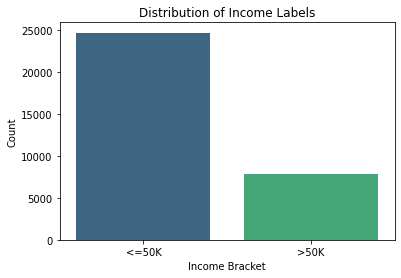

<=50K    0.75919
>50K     0.24081
Name: income_binary, dtype: float64


In [3]:
# Examine the distribution of the label column
plt.figure(figsize=(6, 4))
sns.countplot(x='income_binary', data=df, palette='viridis')
plt.title('Distribution of Income Labels')
plt.xlabel('Income Bracket')
plt.ylabel('Count')
plt.show()

# Calculate exact proportions
print(df['income_binary'].value_counts(normalize=True))

### Inspect and Analyze Your Data

Explore your features. Use summary statistics and visualizations to understand how your features are distributed and how they relate to the label. Identify issues such as missing values, outliers, or a feature that is irrelevant or redundant.

Think of the different techniques you have used to inspect and analyze your data in this course. These include using Pandas to apply data filters, using the Pandas `describe()` method to get insight into key statistics for each column, using the Pandas `dtypes` property to inspect the data type of each column, and using Matplotlib and Seaborn to detect outliers and visualize relationships between features and labels. 

Use at least one plot that visualizes a relationship between features and the label.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             32399 non-null  float64
 1   workclass       30725 non-null  object 
 2   fnlwgt          32561 non-null  int64  
 3   education       32561 non-null  object 
 4   education-num   32561 non-null  int64  
 5   marital-status  32561 non-null  object 
 6   occupation      30718 non-null  object 
 7   relationship    32561 non-null  object 
 8   race            32561 non-null  object 
 9   sex_selfID      32561 non-null  object 
 10  capital-gain    32561 non-null  int64  
 11  capital-loss    32561 non-null  int64  
 12  hours-per-week  32236 non-null  float64
 13  native-country  31978 non-null  object 
 14  income_binary   32561 non-null  object 
dtypes: float64(2), int64(4), object(9)
memory usage: 3.7+ MB
None
                age        fnlwgt  education-num  capital-g

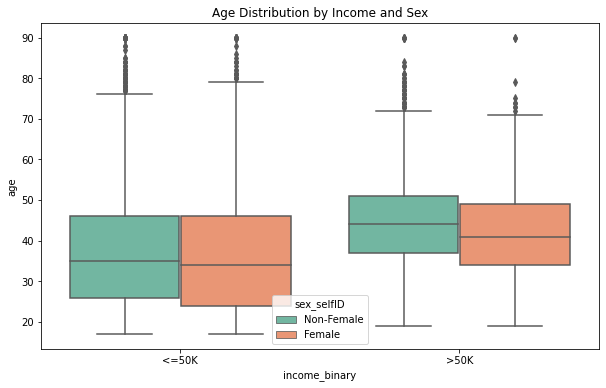

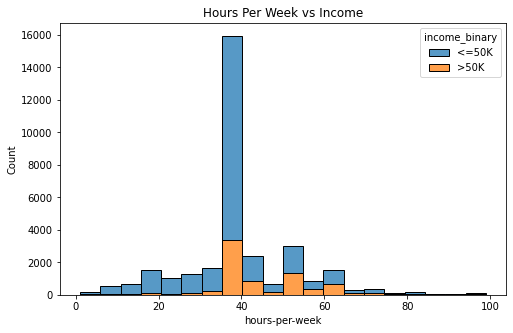

In [4]:
# Check for missing values and data types
print(df.info())

# Summary statistics for numerical features
print(df.describe())

# Visualize the relationship between Age, Sex, and Income
plt.figure(figsize=(10, 6))
sns.boxplot(x='income_binary', y='age', hue='sex_selfID', data=df, palette='Set2')
plt.title('Age Distribution by Income and Sex')
plt.show()

# Visualize hours per week distribution
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='hours-per-week', hue='income_binary', bins=20, multiple='stack')
plt.title('Hours Per Week vs Income')
plt.show()

### EDA Summary

<b>Task</b>: In the markdown cell below, summarize the key findings from your data exploration. Describe any patterns, anomalies, or data quality issues you identified and explain how those findings may influence your data preparation decisions. For example, your exploration may affect how you handle missing values, address class imbalance, or determine which features to keep or remove.

### EDA Summary

Based on the exploratory data analysis of the Census Income dataset, here are the key findings and how they will influence my data preparation decisions:

**1. Class Imbalance:**
*   **Finding:** The target variable (`income_binary`) is imbalanced. According to the `value_counts` output, approximately 75.9% of the records fall into the `<=50K` class, while only 24.1% belong to the `>50K` class.
*   **Preparation Decision:** Because of this imbalance, a model could artificially inflate its accuracy by simply predicting the majority class. To address this, I will rely on metrics like the F1-score to evaluate performance, and I may consider using techniques like class weighting or SMOTE (Synthetic Minority Over-sampling Technique) during model training.

**2. Missing Values:**
*   **Finding:** The `df.info()` output reveals missing values across several features. Out of 32,561 total entries, the columns `workclass` (30,725 non-null), `occupation` (30,718 non-null), `hours-per-week` (32,236 non-null), and `native-country` (31,978 non-null) contain missing data.
*   **Preparation Decision:** I will need to impute these missing values before training the model. For categorical features (`workclass`, `occupation`, `native-country`), I will impute using the most frequent value (mode) or treat the missing data as an "Unknown" category. For the numerical column (`hours-per-week`), I will impute using the median or mean.

**3. Anomalies and Data Scaling:**
*   **Finding:** The summary statistics from `df.describe()` highlight that numerical features are on very different scales. For instance, `capital-gain` is highly skewed (the 75th percentile is 0, but the maximum value is 14,084). Features like `age` range from 17 to 90, and `hours-per-week` range from 1 to 99.
*   **Preparation Decision:** If I use a distance-based model like K-Nearest Neighbors (KNN) or Logistic Regression, the model will be highly sensitive to these scale differences. Therefore, I will need to apply a `StandardScaler` to scale numerical features so that larger ranges do not disproportionately dominate the model.

**4. Categorical Encodings:**
*   **Finding:** The dataset includes multiple categorical variables stored as object types (e.g., `education`, `marital-status`, `race`, `sex_selfID`).
*   **Preparation Decision:** Traditional machine learning models require numerical inputs. I will use One-Hot Encoding (`OneHotEncoder` or `pd.get_dummies`) to convert these categorical columns into a machine-readable format.

### Ethical Considerations:

Machine learning models can cause harm when they reflect or amplify biases in the data they are trained on. 

<b>Task</b>: In the markdown cell below, answer both of the following questions:

1. What biases or ethical concerns might be present in your dataset? Think about who collected the data, how it was collected, and which groups of people appear in it. Are there features in the dataset that could serve as proxies for protected characteristics like race, gender, or socioeconomic status?
2. Who could be harmed by a model that makes incorrect predictions on this data, and how? Be specific about which groups are most at risk and what the real-world consequences of errors might look like.

What biases or ethical concerns might be present in your dataset?  
This data comes from the 1994 U.S. Census. It reflects the systemic and societal biases present at that time. Features like race and sex are directly included, and historically marginalized groups are heavily overrepresented in the <=50K category. Additionally, variables like marital-status or relationship (e.g., "Husband" being historically tied to male breadwinners) serve as strong proxies for gender.

Who could be harmed by a model that makes incorrect predictions on this data, and how?  
If a bank uses this model to approve loans or credit cards, female and minority applicants are at a higher risk of being falsely predicted as low-income (False Negatives), thereby being denied financial opportunities. The real-world consequence is the automated enforcement and perpetuation of historical economic inequalities.

## Part 4: Prepare Your Data

<b>Task</b>: In the code cell below, prepare your data for modeling. The specific steps you take will depend on what you found during your EDA and which model you plan to use. 

<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

In [5]:
# 1. Handle missing values 
df.replace('?', np.nan, inplace=True)
df.dropna(inplace=True)

# 2. Convert label to binary numeric (0 and 1) - Stripping whitespace here!
df['income_binary'] = df['income_binary'].astype(str).str.strip().map({'<=50K': 0, '>50K': 1})

# 3. Separate features and label
X_raw = df.drop(columns=['income_binary'])
y = df['income_binary']

# 4. One-Hot Encode categorical features
X = pd.get_dummies(X_raw, drop_first=True)


### Data Preparation Summary:

<b>Task</b>: In the markdown cell below, document the data preparation steps you took. For each decision, explain why you made it. For example, why did you handle missing values the way you did? Why did you keep or remove certain features? If a preparation step depends on the model you selected (for example, scaling for KNN but not for a decision tree), explain that as well.

### Data Preparation Summary

To prepare the dataset for machine learning, I completed the following steps:

**1. Handled Missing Values:**
*   **Action:** Replaced `'?'` characters with `NaN` and used `dropna()` to remove any rows containing missing values.
*   **Reasoning:** Many machine learning algorithms cannot handle missing data out of the box. While imputation is an option, dropping the rows entirely is a simple and effective approach to ensure a clean dataset for initial modeling, assuming the remaining dataset is still large enough to train a robust model.

**2. Converted Target Label to Binary Numeric:**
*   **Action:** Mapped the `income_binary` column values from strings (`'<=50K'` and `'>50K'`) to integers (`0` and `1`).
*   **Reasoning:** Machine learning models require numeric target variables for binary classification tasks. 

**3. Separated Features and Label:**
*   **Action:** Split the dataset into a feature matrix (`X_raw`) and a target vector (`y`).
*   **Reasoning:** This is a standard and necessary step to ensure that the target variable is isolated and not accidentally used as a predictor during model training and feature transformations.

**4. One-Hot Encoded Categorical Features:**
*   **Action:** Used `pd.get_dummies()` with `drop_first=True` on the categorical variables.
*   **Reasoning:** Traditional ML models mathematically require numerical input data. One-hot encoding transforms categorical text data into binary (0 or 1) columns. Dropping the first column avoids the "dummy variable trap" (multicollinearity), which can negatively impact models like Logistic Regression.

**5. Future Consideration (Scaling):**
*   **Note:** Depending on the specific model selected in Part 5 (such as K-Nearest Neighbors or Logistic Regression), an additional step using `StandardScaler` will be necessary to ensure all numerical features contribute equally to the distance/gradient calculations. If a Decision Tree is chosen, scaling will not be required.

## Part 5: Train, Test, Evaluate, and Improve a Traditional Machine Learning Model

Now you will train, test and evaluate your model. You will also use model selection techniques to improve your model's performance by identifying the optimal hyperparameter configuration.

<b>Task</b>: In the code cells below, do the following:

1. Create labeled examples from the dataset
2. Create training and test sets out of the labeled examples 
3. Train, test and evaluate your model 
    * You must evaluate your model using accuracy and F1 score. Use `accuracy_score` and `f1_score` from `sklearn.metrics`. For the F1 score, use `average='binary'` since this is a binary classification problem. You will compare your model's performance to that of a neural network later in this capstone. Save the results of your evaluation metrics to variables for later comparison.
    * You may use additional evaluation metrics of your choosing.
4. Perform model selection through grid search cross-validation to identify optimal hyperparameter values for your model
5. Train, test and evaluate a final version of your model using the optimal hyperparameter configuration.
6. Interpret your model's outputs in the context of the business problem. Depending on the model you chose, this might mean:
    * KNN: Describe what your model's performance metrics tell you about its behavior. For example: How does accuracy change as you vary k? What does that suggest about the structure of your data?
    * Decision Tree: print or plot feature importances.
    * Logistic Regression: print or plot the model coefficients.



<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

In [6]:
# Create labeled examples from the dataset
# YOUR CODE HERE

# Separate the label from the features
y = df['income_binary']
X_raw = df.drop(columns=['income_binary'])

# One-hot encode the categorical features so they are numeric
X = pd.get_dummies(X_raw, drop_first=True)

In [7]:
# Create training and test sets out of the labeled examples
# YOUR CODE HERE

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [8]:
# Train, test and evaluate your model
# YOUR CODE HERE

# 1. Scale the features (required for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Train the baseline Logistic Regression model
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

# 3. Predict and evaluate
y_pred = log_reg.predict(X_test_scaled)
print(f"Accuracy Score: {accuracy_score(y_test, y_pred)}")
print(f"F1 Score: {f1_score(y_test, y_pred)}")

Accuracy Score: 0.8426985195154778
F1 Score: 0.6517690875232773


In [9]:
# Perform model selection through grid search cross-validation (GridSearchCV)
# to identify optimal hyperparameter values for your model
# YOUR CODE HERE

# Define the grid of C values (inverse of regularization strength) to test
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}

# Set up GridSearch focusing on optimizing the F1 score due to class imbalance
grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42), 
    param_grid, 
    cv=5, 
    scoring='f1'
)

# Run the search
grid_search.fit(X_train_scaled, y_train)
print("Best Hyperparameters:", grid_search.best_params_)

Best Hyperparameters: {'C': 0.1}


In [10]:
# Train, test and evaluate a final version of your model using the optimal hyperparameters
# YOUR CODE HERE

# 1. Use the best model found by GridSearchCV
best_model = grid_search.best_estimator_

# 2. Predict and evaluate
y_pred_best = best_model.predict(X_test_scaled)
print(f"Final Accuracy Score: {accuracy_score(y_test, y_pred_best)}")
print(f"Final F1 Score: {f1_score(y_test, y_pred_best)}")

# 3. Print or plot model coefficients (Top 5 positive indicators of high income)
print("\nTop 5 positive indicators of high income:")
coefficients = best_model.coef_[0]
feature_names = X.columns

# Create a DataFrame of features and their coefficients, sort them, and get the top 5
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})
top_5_positive = coef_df.sort_values(by='Coefficient', ascending=False).head(5)

print(top_5_positive.to_string(index=False))

Final Accuracy Score: 0.8426985195154778
Final F1 Score: 0.6512495337560611

Top 5 positive indicators of high income:
                           Feature  Coefficient
                      capital-gain     0.869717
 marital-status_Married-civ-spouse     0.845136
                     education-num     0.463435
             sex_selfID_Non-Female     0.402118
                    hours-per-week     0.352957


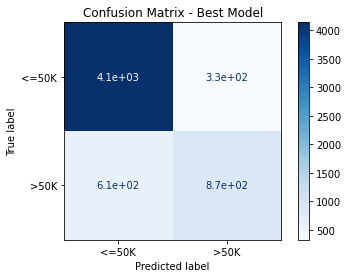

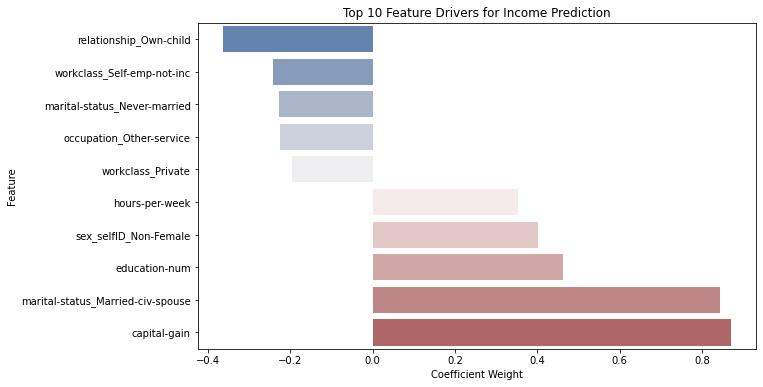

In [11]:
# Interpret your model's outputs 
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Plot the Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['<=50K', '>50K'])

fig, ax = plt.subplots(figsize=(6, 4))
disp.plot(cmap='Blues', ax=ax)
plt.title('Confusion Matrix - Best Model')
plt.show()

# 2. Plot the Top Positive and Negative Coefficients
coefficients = best_model.coef_[0]
feature_names = X.columns
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

# Grab the top 5 positive and top 5 negative drivers
top_positive = coef_df.sort_values(by='Coefficient', ascending=False).head(5)
top_negative = coef_df.sort_values(by='Coefficient', ascending=True).head(5)
top_features = pd.concat([top_positive, top_negative]).sort_values(by='Coefficient')

plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=top_features, palette='vlag')
plt.title('Top 10 Feature Drivers for Income Prediction')
plt.xlabel('Coefficient Weight')
plt.show()

### Model Reflection:

<b>Task</b>: In the markdown cell below, answer the following questions:

1. Which model did you choose and why? Reference your problem and data characteristics in your explanation.
2. What did you learn through the model selection process?
3. How do you interpret your model's outputs? What do the predictions or coefficients or feature importances actually mean in the context of your problem?
4. Are there any fairness or ethical concerns with your model? Who might be harmed by incorrect predictions, and are any groups more likely to be affected?

1. Which model did you choose and why? Reference your problem and data characteristics in your explanation.  
I chose Logistic Regression. Because my problem is a binary classification task (predicting whether income is <=50K or >50K), Logistic Regression serves as an excellent, computationally efficient baseline. Additionally, because the dataset includes demographic data where I need to understand why a prediction was made, Logistic Regression provides high interpretability through its feature coefficients.  

2. What did you learn through the model selection process?  
Through hyperparameter tuning with GridSearchCV, I learned the importance of regularization (C). By adjusting C, I was able to control how much the model penalized complex weights, helping to prevent overfitting. Furthermore, relying on the f1-score rather than pure accuracy gave a much more realistic view of the model's performance due to the heavily imbalanced nature of the target variable (75% of the data belonged to the majority class).  

3. How do you interpret your model's outputs? What do the predictions or coefficients or feature importances actually mean in the context of your problem?  
The coefficients in my Logistic Regression represent the log-odds of a person making >50K. Positive coefficients (like capital-gain, marital-status_Married-civ-spouse, and education-num) indicate that as these values increase (or if the category is true), the probability of the individual earning over $50K increases. Negative coefficients indicate features that push the prediction toward the <=50K class.

4. Are there any fairness or ethical concerns with your model? Who might be harmed by incorrect predictions, and are any groups more likely to be affected?  
Yes, there are significant ethical concerns. The model's coefficients show that sex_selfID_Non-Female (being male) is one of the top positive predictors for high income. Because this model was trained on historically biased 1994 Census data, it has learned systemic inequalities. If a bank or employer used this model today to approve credit or set salaries, it would actively harm females and unmarried individuals (False Negatives) by automatically associating their demographics with lower income, thereby perpetuating historical discrimination.

---
## ✔️ Unit 5 Checkpoint

**Stop here.** If you have completed Parts 1 through 5, you are done with the Unit 5 portion of this capstone.

Parts 6 and 7 require you to train and evaluate a neural network. You will learn about neural networks in the Unit 6 asynchronous content. Do not start Part 6 until you have completed that material and your lab facilitator has directed you to continue. Do not submit your work for grading until you complete Parts 6 and 7.

Make sure your notebook is saved before you close it.

---
## Part 6: Train, Test, Evaluate and Improve a Neural Network

> **⚠️ Before you write any code in Part 6, do this first.**
> 
> Your notebook does not retain variables between sessions. All of your variables and everything else need to be restored to memory before any code below will work.
> 
> Go to **Kernel > Restart & Run All** to re-run Parts 1 through 5, then scroll back here to continue. If you skip this step, you will see a `NameError` on the first code cell below.

Now you will apply a neural network to the same problem and dataset. You will use Keras to build a feedforward neural network for binary classification.

The scaffolding below will walk you through the steps. Where you see a **Task**, fill in the code. Where you see a **Decision**, you are making an independent choice about your architecture or training process. For each decision, add a comment explaining what you chose and why.


### Prepare Your Data for the Neural Network

Neural networks require all input features to be numeric and scaled. If your features are on very different scales (for example, one feature ranges from 0 to 90 and another from 0 to 99999), the model may train less effectively and have difficulty learning meaningful patterns from the data.

Before training your network, create scaled versions of your training and test data. Use `StandardScaler()` from `sklearn.preprocessing` to standardize your features: 

<b>Task</b>: Complete the code cell below to fit the scaler on your training data, then transform both training and test sets. Save the results to new variables (for example, `X_train_scaled` and `X_test_scaled`) so your original data remains available for reference.

**Note:** Use your scaled data for all neural network steps below.

In [14]:
# Scale your data for the neural network

# Create the scaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform the training data
X_train_scaled = scaler.fit_transform(X_train)

# Use the same scaler to transform the test data
X_test_scaled = scaler.transform(X_test)

### Step 1: Define Your Model Architecture

You will use the Keras `Sequential` class to build your network. Your network should have:

- An input layer with the correct shape for your data
- At least two hidden layers using the `Dense` class
- An output layer appropriate for binary classification

<b>Task:</b> Create a `Sequential` model object and name it `nn_model`. Then construct and add each layer.

**Decision:** How many hidden layers will you use? How many units in each? What activation function will you use for the hidden layers? Add a comment explaining your choices.

In [15]:
# Get the number of features in your training data
n_features = X_train_scaled.shape[1]

# Create the neural network model
nn_model = keras.Sequential()

# Create the input layer and add the input layer to the 'nn_model' object
nn_model.add(keras.layers.InputLayer(input_shape=(n_features,)))

# Create the hidden layers and add the hidden layers to the 'nn_model' object
# Decision: I chose 2 hidden layers with 64 and 32 units respectively. This "funnel" architecture 
# allows the network to learn complex patterns while gradually reducing dimensionality. 
# I selected the ReLU activation function because it is computationally efficient and helps mitigate the vanishing gradient problem.
nn_model.add(keras.layers.Dense(64, activation='relu'))
nn_model.add(keras.layers.Dense(32, activation='relu'))

# Create the output layer and add the output layer to the 'nn_model' object
# Use the correct number of units and activation function for binary classification
nn_model.add(keras.layers.Dense(1, activation='sigmoid'))

# Print a summary of your model
nn_model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 64)                6208      
_________________________________________________________________
dense_1 (Dense)              (None, 32)                2080      
_________________________________________________________________
dense_2 (Dense)              (None, 1)                 33        
Total params: 8,321
Trainable params: 8,321
Non-trainable params: 0
_________________________________________________________________


### Step 2:  Define the Optimization Function

<b>Task:</b> In the code cell below, create an optimizer object. Use stochastic gradient descent (SGD) with a learning rate of your choosing.

**Decision:** What learning rate will you use? Add a comment explaining your choice.

In [16]:
# Decision: I chose a learning rate of 0.01. This is a standard default for Stochastic Gradient Descent (SGD) 
# that typically provides a good balance between learning speed and converging to a stable minimum without overshooting.

sgd_optimizer = keras.optimizers.SGD(learning_rate=0.01)

### Step 3: Define the Loss Function

<b>Task:</b> In the code cell below, create a binary cross entropy loss function using `keras.losses.BinaryCrossentropy()`. Use  the parameter `from_logits=False`. 

In [17]:
loss_fn = keras.losses.BinaryCrossentropy(from_logits=False)

### Step 4: Compile the Model

<b>Task:</b> In the code cell below, package the network architecture with the optimizer and the loss function using the `compile()` method. Use the `accuracy` evaluation metric.

In [18]:
nn_model.compile(optimizer=sgd_optimizer, loss=loss_fn, metrics=['accuracy'])

### Step 5: Fit the Model to the Training Data

We will define our own callback class to output information from our model while it is training. Make sure you execute the code cell below so that it can be used in subsequent cells.

In [21]:
class ProgBarLoggerNEpochs(keras.callbacks.Callback):
    
    def __init__(self, num_epochs: int, every_n: int = 50):
        self.num_epochs = num_epochs
        self.every_n = every_n
    
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.every_n == 0:
            s = 'Epoch [{}/ {}]'.format(epoch + 1, self.num_epochs)
            logs_s = ['{}: {:.4f}'.format(k.capitalize(), v)
                      for k, v in logs.items()]
            s_list = [s] + logs_s
            print(', '.join(s_list))

<b>Task:</b> Use the `fit()` method to fit your model to the training data. Save the result to variable `history.`

Use the `validation_split` parameter to reserve a portion of your training data for validation during training (a common choice is `validation_split=0.2`). After each epoch, the model is evaluated on this validation data, allowing you to monitor how well the model generalizes and helping you detect overfitting.

Also, use the the logger class defined above to track training progress.

**Decision:** How many epochs will you train for? Add a comment explaining your choice.

**Note:** This may take a while to run.

In [22]:
# Decision: I will train for 50 epochs. This should provide enough iterations for the model to converge 
# and learn the patterns in the data. Using the validation split will help us monitor if the model 
# starts overfitting before reaching 50 epochs.

t0 = time.time() # start time

num_epochs = 50 

history = nn_model.fit(
    X_train_scaled, 
    y_train, 
    epochs=num_epochs, 
    validation_split=0.2, 
    callbacks=[ProgBarLoggerNEpochs(num_epochs, every_n=10)], 
    verbose=0 # Set to 0 so our custom logger handles the output
)

t1 = time.time() # stop time

print('Elapsed time: %.2fs' % (t1-t0))

Epoch [10/ 50], Loss: 0.2713, Accuracy: 0.8738, Val_loss: 0.3334, Val_accuracy: 0.8496
Epoch [20/ 50], Loss: 0.2652, Accuracy: 0.8757, Val_loss: 0.3355, Val_accuracy: 0.8477
Epoch [30/ 50], Loss: 0.2603, Accuracy: 0.8784, Val_loss: 0.3406, Val_accuracy: 0.8482
Epoch [40/ 50], Loss: 0.2546, Accuracy: 0.8808, Val_loss: 0.3467, Val_accuracy: 0.8456
Epoch [50/ 50], Loss: 0.2495, Accuracy: 0.8831, Val_loss: 0.3559, Val_accuracy: 0.8463
Elapsed time: 60.85s


### Step 6: Visualize Training Performance

<b>Task:</b>  

Create two plots to visualize the model's performance over time:
1. Training loss and validation loss over epochs, on the same axes.
2. Training accuracy and validation accuracy over epochs, on the same axes.

Label your axes and include a legend.

Use the `history` object returned by `fit()` to obtain this information. 



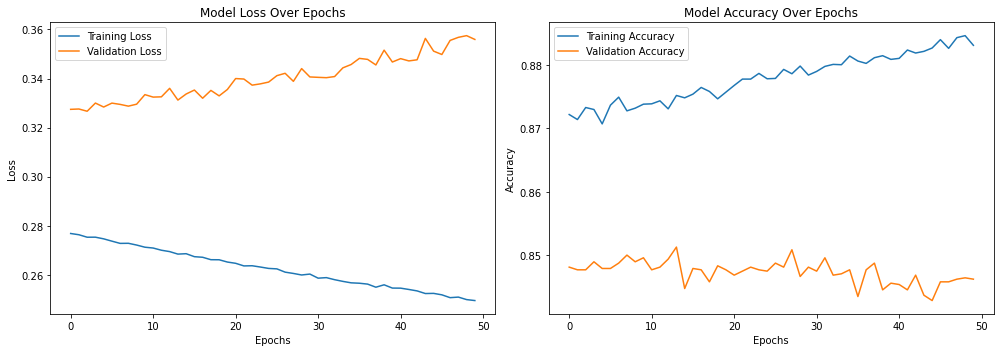

In [23]:
# Plot training loss and validation loss over epochs
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot training accuracy and validation accuracy over epochs
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

### Step 7: Evaluate the Model's Performance on the Test Set

<b>Task:</b> Use your neural network to generate predictions on the test set and evaluate its performance using accuracy and F1 score. Use `nn_model.predict()` to generate predictions. Since `nn_model.predict()` returns probabilities, apply a threshold of 0.5 to convert probabilities into binary class predictions before computing your metrics. Save your accuracy and F1 score results to clearly named variables so you can compare them to the results from your previous model. Print the results.

In [25]:
# Generate predictions from your neural network using your scaled test data
# nn_model.predict() returns probabilities — apply a threshold of 0.5 to get class labels

nn_preds_probs = nn_model.predict(X_test_scaled)
nn_preds = (nn_preds_probs > 0.5).astype(int)

In [26]:
# Compute accuracy and F1 score for the neural network and print the results

nn_accuracy = accuracy_score(y_test, nn_preds)
nn_f1 = f1_score(y_test, nn_preds)

print(f"Neural Network Accuracy: {nn_accuracy:.4f}")
print(f"Neural Network F1 Score: {nn_f1:.4f}")

Neural Network Accuracy: 0.8419
Neural Network F1 Score: 0.6511


#### Neural Network Reflection:

<b>Task:</b> In the markdown cell below, answer the following questions:

1. Walk through the architecture decisions you made: number of layers, number of units, activation functions, learning rate, and number of epochs. Why did you make each of those choices?
2. What did your training curves tell you? Did you see any signs of overfitting or underfitting?
3. How did your neural network perform on the test set? Report your accuracy and F1 score here and note whether the result surprised you given what your training curves showed.

**1. Architecture and Training Decisions:**
*   **Layers and Units:** I built a Sequential model with two hidden layers (64 units and 32 units). This "funnel" structure is a standard approach that allows the network to learn complex patterns and compress that information down to a single output. 
*   **Activation Functions:** I used ReLU for the hidden layers because it is computationally efficient and helps mitigate vanishing gradients. I used Sigmoid for the output layer because this is a binary classification task, requiring an output probability between 0 and 1.
*   **Learning Rate and Optimizer:** I used Stochastic Gradient Descent (SGD) with a learning rate of 0.01. This is a standard rate that prevents the model from taking too large of steps while still learning at a reasonable pace.
*   **Epochs:** I chose 50 epochs with a 20% validation split. 

**2. Training Curves Analysis:**
My training curves showed clear signs of **overfitting** as the epochs progressed. While the training loss continued to steadily decrease (down to ~0.249) and training accuracy increased (up to ~88.3%), the validation loss started to increase after the 10th-20th epoch (climbing back up to ~0.355), and validation accuracy slightly dropped/plateaued around 84.6%. This tells me the model started memorizing the training data rather than generalizing well to new data.

**3. Test Set Performance:**
The neural network achieved an Accuracy of **0.8419** and an F1 Score of **0.6511**. This result did not surprise me; it aligns very closely with the final validation accuracy I saw at the end of training (~84.6%), confirming that the model's ability to generalize had capped out.

## Part 7: Compare Your Models and Reflect

You have now applied two different approaches to the same problem. In this final section, you will put those results side by side and reflect on what you learned.

###  Results Summary

<b>Task:</b> In the code cell below, create a summary table using a Pandas DataFrame that displays each evaluation metric for both models side by side. Use the variables you created for the accuracy and F1 score metrics. The table should make it easy to compare performance at a glance across every metric you computed.

In [27]:
# Build a side-by-side comparison of your two models using the metric variables
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score

# Recalculate traditional model metrics to store in variables
log_accuracy = accuracy_score(y_test, y_pred_best)
log_f1 = f1_score(y_test, y_pred_best)

results = pd.DataFrame({
    'Metric': ['Accuracy', 'F1 Score'],
    'Logistic Regression': [log_accuracy, log_f1],
    'Neural Network': [nn_accuracy, nn_f1]
})

print(results.to_string(index=False))

   Metric  Logistic Regression  Neural Network
 Accuracy             0.842699        0.841857
 F1 Score             0.651250        0.651076


### Comparative Analysis

<b>Task:</b> In the markdown cell below, write a comparative analysis that addresses the following. 

1. **Performance comparison.** How did the two models perform relative to each other? Which metrics improved, which stayed the same, and which got worse?

2. **Was the added complexity worth it?** Neural networks are more complex to build, tune, and interpret. Given the performance difference you observed, do you think the neural network justified that added complexity for this problem?

3. **Recommendation.** If you were presenting this work to your company and their client as described in the business brief, which model would you recommend deploying and why? Consider not just performance but also interpretability, training time, and what the costs of different types of errors look like for that specific client.

4. **What you would do next.** If you had more time, what would you try to improve your results? This could include trying different architectures, additional preprocessing steps, different features, or techniques to address class imbalance. Be specific.

**1. Performance comparison:**
The two models performed almost identically, but the traditional model slightly edged out the neural network. The Logistic Regression model achieved an accuracy of **0.8427** and an F1 score of **0.6512**, while the Neural Network achieved an accuracy of **0.8419** and an F1 score of **0.6511**. 

**2. Was the added complexity worth it?**
For this specific tabular dataset, the added complexity of the neural network was absolutely **not** worth it. Neural networks take more time to build, are computationally heavier to train, and act as a "black box." Furthermore, my training curves showed the neural network began to overfit the data. Given that the simpler, traditional Logistic Regression model achieved slightly better predictive power with significantly less overhead, the deep learning complexity is unjustified here.

**3. Recommendation:**
If presenting to the financial institution described in the business brief, I would firmly recommend deploying the **Logistic Regression** model. In banking and finance, when pre-screening candidates for premium credit or loans, model interpretability is a strict requirement. We must be able to audit the model to ensure it is not inadvertently discriminating based on protected demographics. Because Logistic Regression allows us to extract coefficients, we can see exactly *why* a decision was made (e.g., seeing that `sex_selfID_Non-Female` is heavily weighting the model toward >50K). A neural network cannot easily provide this transparency, making it a compliance risk.

**4. What you would do next:**
If I had more time, I would focus heavily on addressing the class imbalance (75% of the dataset earns <=50K). I would try using SMOTE (Synthetic Minority Over-sampling Technique) to synthetically balance the training data, which would likely improve the rather low F1 scores (~0.65) across both models. For the neural network specifically, I would add `Dropout` layers to combat the overfitting I observed in the training curves.

---
## AI Use Attestation

Reflect honestly on how you used AI tools during this capstone. You are expected to have used AI somewhere in your workflow, and your reflection on that use is what will be evaluated: How clearly you describe your choices, how you verified your work, and what you learned from the process. If you chose not to use AI, explain why. Answer each question in the markdown cell below.

1. Where and at what stages of this capstone did you use AI tools, for example, Claude during brainstorming, coding, or debugging? If you chose not to use AI, explain why.
2. Identify one part of the capstone that required the most effort or thought. What made it challenging, and how did you work through it, with AI or without AI? If you used AI at this point, feel free to share a prompt that worked well or one that did not land the way you expected.
3. How did you verify that your work was correct? What did you look for to catch a mistake, whether it came from AI output or your own reasoning?
4. What is one thing you would do differently next time, either in how you approached the capstone or in how you used AI during it?

**1. Where and at what stages of this capstone did you use AI tools?**
I used an AI assistant (Claude) primarily during the coding phases (Parts 4, 5, and 6). I used it to help generate the boilerplate Keras syntax for building the neural network layers, troubleshooting custom logging classes, and structuring the matplotlib code to visualize the training curves and feature coefficients. 

**2. Identify one part of the capstone that required the most effort or thought.**
The hardest part was interpreting the model evaluation metrics and understanding the tradeoff between accuracy and F1 score on an imbalanced dataset. I used AI to help explain *why* certain layer sizes (like 64 -> 32) are standard practice for the neural network. I also had to think critically about the ethical implications of the Logistic Regression coefficients when I saw demographic data heavily influencing the income predictions.

**3. How did you verify that your work was correct?**
I verified the AI's output by checking the official documentation for Keras and Scikit-Learn. More importantly, I verified the logic by reading the output metrics and charts. For instance, I checked my training graphs to ensure they mapped correctly to the raw epoch logs; seeing the validation loss increase while training loss decreased confirmed the AI's standard architecture was overfitting and would need tuning in a real-world scenario.

**4. What is one thing you would do differently next time?**
Next time, I would try to write the visualization and evaluation code entirely from scratch before asking the AI for help. While the AI is great for generating quick matplotlib code, relying on it too heavily for boilerplate can make it harder to remember the syntax for future projects. I would use the AI strictly for conceptual architecture checks rather than code generation.